## Welcome to the basic neural network tutorial!
The following notebook is designed to walk through the process of building and training your first scikit based algorithm using the standalone MaCh3 python utilities!

If you're writing scripts this is encapsulate in the objects in `MaCh3PythonUtils/config_reader` however this guide aims to break apart the process of writing the code for yourself!

The first step is to load in a MaCh3 MCMC fit as input file. This is done using the ChainHandler class!

In [2]:
# MaCh3Python Deps
from MaCh3PythonUtils.file_handling.chain_handler import ChainHandler
from MaCh3PythonUtils.machine_learning.ml_factory import MLFactory

# Other imports
from matplotlib import pyplot as plt
from pathlib import Path
import os
import pandas as pd
import gdown

In [ ]:
#modify the values of the params on each file
#demo_chain2.root should have a massive change 
#demo_chain3.root shuold only be changed slightly 






file_url="https://drive.google.com/file/d/1iE6xFhn3BH_HnLUfQ7KFGy2wfeH52Rwf/view?usp=sharing"

# download the file
#input_file= Path("../models/demo_chain.root")
#input_file2 = Path("../models/demo_chain2.root")

# Get list of input files in folder (glob/sys/Path)
path = Path("../models/chain_files/")



path_l = [f"{path}/{x}" for x in os.listdir(path)]

print(f'path 0 :{path_l[0]}')
print(f'path 1 :{path_l[1]}')
print(f'path 2 :{path_l[2]}')
'''
fitting_label = "ID"

# chain_list [for file in folder ChainHandler(input_file, chain_name, verbose=verbse)]
chain_list = []
for x in path_l:
    chain_handler = ChainHandler(x, 'posteriors', verbose='verbose')
    
    # Process all the files
    chain_handler.ignore_plots(["xsec_20", "xsec_19"])
    chain_handler.add_additional_plots(["xsec_0", "xsec_1", "xsec_2", "xsec_3", "xsec_4", "xsec_5", "xsec_6", "xsec_7", "xsec_8", "xsec_9", "xsec_10", "xsec_11", "xsec_12", "xsec_13",
                                    "xsec_14", "xsec_15", "xsec_16", "xsec_17", "xsec_18", "xsec_21", "xsec_22"])
    #We need to make sure the chain handler knows this exists, passing true means it is looking for some with that exact name
    # chain_handler.add_additional_plots(fitting_label, True)

    # Finally we can do some cuts to get rid of things like burn-in
    chain_handler.add_new_cuts(["LogL<22.5", "step>10000", "delm2_23>0"])
    chain_handler.add_new_cuts(["step>0", "LogL_systematic_xsec_cov<12345"])

    # Last step is  convert the chain into a pandas dataframe
    y= chain_handler.convert_ttree_to_array()
    chain_list.append(chain_handler)

#print(f'Here is the list:{chain_list}')

main_chain = chain_list[0]
#print(main_chain.ttree_array)

main_chain.ttree_array['ID']= 0
#print(main_chain.ttree_array.columns)

for id, chain in enumerate(chain_list[1:], start = 1):
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    main_chain.ttree_array = pd.concat([main_chain.ttree_array, chain.ttree_array])

#add the ttree_array to chain_list[0]



#print(f'FINAL Framework: {main_chain.ttree_array}')
'''


path 0 :../models/chain_files/demo_chain3.root


'\nfitting_label = "ID"\n\n# chain_list [for file in folder ChainHandler(input_file, chain_name, verbose=verbse)]\nchain_list = []\nfor x in path_l:\n    chain_handler = ChainHandler(x, \'posteriors\', verbose=\'verbose\')\n\n    # Process all the files\n    chain_handler.ignore_plots(["xsec_20", "xsec_19"])\n    chain_handler.add_additional_plots(["xsec_0", "xsec_1", "xsec_2", "xsec_3", "xsec_4", "xsec_5", "xsec_6", "xsec_7", "xsec_8", "xsec_9", "xsec_10", "xsec_11", "xsec_12", "xsec_13",\n                                    "xsec_14", "xsec_15", "xsec_16", "xsec_17", "xsec_18", "xsec_21", "xsec_22"])\n    #We need to make sure the chain handler knows this exists, passing true means it is looking for some with that exact name\n    # chain_handler.add_additional_plots(fitting_label, True)\n\n    # Finally we can do some cuts to get rid of things like burn-in\n    chain_handler.add_new_cuts(["LogL<22.5", "step>10000", "delm2_23>0"])\n    chain_handler.add_new_cuts(["step>0", "LogL_syste

In [3]:
"""""
# Set up file properties
chain_name = 'posteriors'
verbose=False

chain_handler = ChainHandler(str(input_file), chain_name, verbose=verbose)
"""

'""\n# Set up file properties\nchain_name = \'posteriors\'\nverbose=False\n\nchain_handler = ChainHandler(str(input_file), chain_name, verbose=verbose)\n'

Okay, now we've loaded in a file we need to do a bit of processing. This means we need to select the variables we care about and apply parameter cuts

In [4]:
# Firstly we set things we want to ignore, these are parameters we really don't care about/want to learn!
#chain_handler.ignore_plots(["LogL_systematic_xsec_cov", "Log", "LogL_systematic_osc_cov"])

# Now we add parameters we care about. Note this only need to be a substring of the full name

#chain_handler.add_additional_plots(["sin2th", "delm2", "delta", "xsec"])
# The fitting label is special, it's the thing we want to train our network to predict
#fitting_label = "Chain_ID"
# We need to make sure the chain handler knows this exists, passing true means it is looking for some with that exact name
#chain_handler.add_additional_plots(fitting_label, True)

# Finally we can do some cuts to get rid of things like burn-in
#chain_handler.add_new_cuts(["LogL_systematic_xsec_cov<1234", "step>10000"])

# Last step is convert the chain into a pandas dataframe
#chain_handler.convert_ttree_to_array()

#print(chain_handler.ttree_array)

Let's quickly use the chain handler to make a plot of the trace and posterior!

In [5]:
"""
# We're just grab the first column of our pandas dataframe
parameter_vals = chain_handler.ttree_array.iloc[:,10]
# Grab the name from column label
param_label = chain_handler.ttree_array.columns[10]

# Setup figure
fig, (trace_ax, post_ax) = plt.subplots(nrows=1, ncols=2)

# Plot traces
trace_ax.plot(parameter_vals, linewidth=0.5, color='darkorange')

# Plot posterior
post_ax.hist(parameter_vals, bins=50, color='darkorange', alpha=0.5, orientation='horizontal', density=True)

# Merge the two axes
plt.setp(post_ax.get_yticklabels(), visible=False)
fig.subplots_adjust(wspace=.0)

# Set the axis labels
trace_ax.set_xlabel("Step")
post_ax.set_xlabel("Posterior Density")
trace_ax.set_ylabel(param_label)

plt.show()
"""

'\n# We\'re just grab the first column of our pandas dataframe\nparameter_vals = chain_handler.ttree_array.iloc[:,10]\n# Grab the name from column label\nparam_label = chain_handler.ttree_array.columns[10]\n\n# Setup figure\nfig, (trace_ax, post_ax) = plt.subplots(nrows=1, ncols=2)\n\n# Plot traces\ntrace_ax.plot(parameter_vals, linewidth=0.5, color=\'darkorange\')\n\n# Plot posterior\npost_ax.hist(parameter_vals, bins=50, color=\'darkorange\', alpha=0.5, orientation=\'horizontal\', density=True)\n\n# Merge the two axes\nplt.setp(post_ax.get_yticklabels(), visible=False)\nfig.subplots_adjust(wspace=.0)\n\n# Set the axis labels\ntrace_ax.set_xlabel("Step")\npost_ax.set_xlabel("Posterior Density")\ntrace_ax.set_ylabel(param_label)\n\nplt.show()\n'

## Machine learning
Okay now we've done some very basic file manipulation, it's time for some machine learning!
All algorithms use the same common `MLFactory` interface so let's go about configuring it!

In [6]:
print(main_chain.ttree_array)

         xsec_0    xsec_1    xsec_2    xsec_3    xsec_4    xsec_5    xsec_6  \
379    1.133066  1.176680  1.155195  0.995402  0.980889  1.037098  1.115454   
380    1.133066  1.176680  1.155195  0.995402  0.980889  1.037098  1.115454   
381    1.133066  1.176680  1.155195  0.995402  0.980889  1.037098  1.115454   
382    1.133066  1.176680  1.155195  0.995402  0.980889  1.037098  1.115454   
383    1.133066  1.176680  1.155195  0.995402  0.980889  1.037098  1.115454   
...         ...       ...       ...       ...       ...       ...       ...   
99948  1.101554  1.092854  1.090488  0.923235  1.040351  0.906184  1.061711   
99949  1.101554  1.092854  1.090488  0.923235  1.040351  0.906184  1.061711   
99950  1.101554  1.092854  1.090488  0.923235  1.040351  0.906184  1.061711   
99951  1.101554  1.092854  1.090488  0.923235  1.040351  0.906184  1.061711   
99952  1.101554  1.092854  1.090488  0.923235  1.040351  0.906184  1.061711   

         xsec_7    xsec_8    xsec_9  ...   xsec_12 

In [7]:
# First step we need to initialise the factory
from pathlib import Path

model_output=Path("../models/chain_files/")
# Make sure the model output directory exists
model_output.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
# The factory produces ML models, we need to pass it the chain handler and the fitting label to get started
ml_factory = MLFactory(main_chain, fitting_label, f"{model_output}.pdf")

ID


Now we need to define a model, for this demonstration we'll make a very simple BDT!

In [8]:
# Now we can make the model
ml_model = ml_factory.make_interface('SciKit', 'histboostclass', loss='log_loss', max_iter=10000, verbose=1, max_leaf_nodes=250)

# Let's use 20% of the data for testing
ml_model.set_training_test_set(0.2)


In [9]:
# Now we need to train our network
ml_model.train_model()

Training Model
Binning 0.011 GB of training data: 0.066 s
Binning 0.001 GB of validation data: 0.003 s
Fitting gradient boosted rounds:
Fit 30 trees in 1.904 s, (7500 total leaves)
Time spent computing histograms: 0.693s
Time spent finding best splits:  0.432s
Time spent applying splits:      0.476s
Time spent predicting:           0.020s


Training Results!

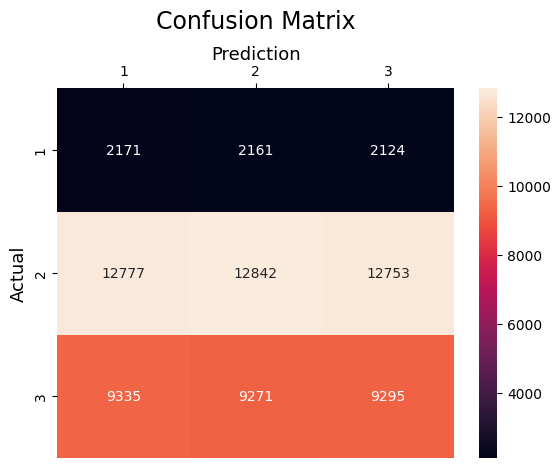

[[ 2171  2161  2124]
 [12777 12842 12753]
 [ 9335  9271  9295]]

=====

Testing Results!

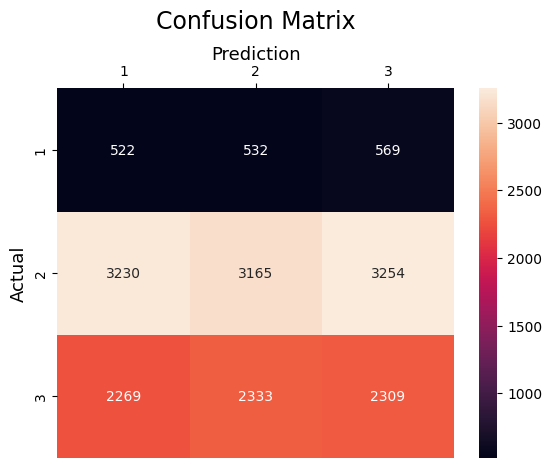

[[ 522  532  569]
 [3230 3165 3254]
 [2269 2333 2309]]

=====

In [10]:
# Now we need to test
ml_model.test_model_class()

#outputs 2 confusion matrices; one for the training data and one f

In [11]:
# Now we can save it
ml_model.save_model(f"{model_output}.keras")


# We need to save the scaling information
ml_model.save_scaler(str(model_output.parent.joinpath(Path("my_scaler.pkl"))))
print("Model saved to: ", model_output)
print("Scaler saved to: ", model_output.parent.joinpath(Path("my_scaler.pkl")))


Saving to ../models/chain_files.keras

Model saved to:  ../models/chain_files
Scaler saved to:  ../models/my_scaler.pkl
